<a href="https://colab.research.google.com/github/larissamitrof-collab/MVP-1/blob/main/MVP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas
Nome: Larissa Mitrof de Lima

Matrícula: 4042025002045

Dataset: Análise do sono, tempo de tela e estresse

# Descrição do Problema
Diversas pesquisas nacionais e internacionais concluem que a utilização de telas à noite influenciam na má qualidade do sono, que por sua vez está associado ao estresse.

Este conjunto de dados multivariado explora a relação entre o uso de smartphones antes de dormir, os padrões de sono e os níveis de estresse para cada usuário.

O Objetivo desta análise é verificar se há correlação direta ou indireta entre os atributos tempo de tela, qualidade do sono e níveis de estresse e se há alguma diferença quando observados gênero e ocupação dos usuários.

## Hipóteses do Problema



1.   Existe diferenças entre gêneros ou ocupação em relação ao tempo de uso de  tela e níveis de estresse?
2.   O uso de telas impacta diferentemente homens emulheres quanto a qualidade do sono?
3. O nível de esgotamento mental é maior em mulheres ou homens?


## Tipo de Problema
Devido a quantidade de atributos e na ausência de rótulos pré-estabelecidos. Seria adequado avaliar este problema através da clusterização,  com o objetivo de organizar os dados não rotulados em grupos com atributos próximos e futuramente elaborar um modelo capaz de prever a qualidade do sono ou níveis de estresse de indivíduos de acordo com o perfil de utilização de smartphones.


## Seleção de Dados

Este conjunto de dados explora a relação entre o uso de smartphones, padrões de sono e níveis de estresse. Com o uso crescente de dispositivos móveis, entender como o tempo de tela afeta a qualidade do sono e o bem-estar mental tornou-se uma área importante de pesquisa.


## Atributos do Dataset

O dataset sobre Análise do sono, tempo de tela e estresse possui um conjunto de dados com 15.000 registros sintéticos representando indivíduos com diferentes estilos de vida, ocupações e hábitos de uso de dispositivos móveis. Ele fornece fatores como tempo de tela, uso do celular antes de dormir, consumo de cafeína e tempo atividade física e resultados  sobre o tempo e qualidade do sono e os níveis de estresse de cada usuário. Fonte: Kaggle



* user_Id: Identificação do usuário.
* age: Idade do Usuário
* gender: Gênero do usuário.
* Occupation: Profissão do Usuário.
* daily_screen_time_hours: Horas diárias de tempo de tela (em horas). Tempo total gasto utilizando dispositivos digitais ou smatphones durante o dia.
* phone_usege_before_sleep_minutes: Uso do telefone (em minutos) antes de dormir.
* sleep_duration_hours: Tempo total (em horas) que o individuo tem por noite.
* sleep_quality_score: Pontuação de qualidade do sono, variando entre 1(ruim) a 10(excelente).
* stress_level: nível de estresse do usuário, medido em uma escala de 1 (baixo) a 10 (alto estresse).
* caffeine_intake_cups: Número de bebidas com cafeína ingeridas por dia pelo usuário.
* physical_activity_minutes: Total de minutos dedicados à atividade física ou exercícios por dia.

* notifications_received_per_days: Número total de notificações recebidas em um smartphone por dia.

* mental_fatigure_score: Pontuação que representa os níveis de fadiga mental, variando de 1 (baixa fadiga) a 10 (alta fadiga).



# Importação das Bibliotecas Necessárias e Carga de Dados

In [442]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [453]:
#Carregamento da base de dados do GitHub
tabela = 'https://raw.githubusercontent.com/larissamitrof-collab/MVP-1/main/sleep_mobile_stress_dataset_15000.csv'

In [454]:
#Dataframe para a base de dados
df = pd.read_csv(tabela)

# Análise dos Dados
Execução da Análise Exploratória dos Dados sobre o dataset  "Análise do sono, tempo de tela e estresse". Aqui, o objetivo será compreender a distribuição, as relações e as características das variáveis, para que seja possível a realização de pré-processamento e modelagem futuramente.

In [405]:
#exibição das primeiras linhas
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


In [406]:
df.tail() #xibição das últimas linhas


,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
14995,14996,39,Male,Manager,8.05,45,8.91,4.33,10.00,1,40,259,10.00
14996,14997,22,Female,Student,6.44,80,6.00,5.22,10.00,2,41,231,7.54
14997,14998,51,Female,Software Engineer,7.01,78,7.27,5.37,8.66,4,93,288,7.78
14998,14999,56,Female,Software Engineer,7.89,6,5.70,5.71,9.56,1,91,47,9.98
14999,15000,20,Female,Freelancer,6.05,93,4.74,5.04,9.33,0,117,64,9.26


## Total e Tipo de Instância

O dataset contém 15.000 instâncias, cada uma representando um indivíduo, com variáveis relacionadas a uso de smartphone, sono, estresse e hábitos diários. Todas as colunas estão completas (sem valores nulos).

O dataset apresenta:


*   2 atributos categóricos (object): gender e ocupation.
*   5 atributos numéricos do tipo (Float): daily_screen_time_hours, sleep_duration_hours, sleep_quality_score, stress_level e mental_fatigue_score.
*  6 atributos numéricos do tipo (int): user_id, age,phone_usage_before_sleep_minutes, caffeine_intake_cups, physical_activity_minutes, notifications_received_per_day.

In [407]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 15000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notification

## Distribuição dos atributos categóricos
Análise da distribuição das instâncias por atributos categóricos de gênero e ocupação.

###Distribuição por Gênero

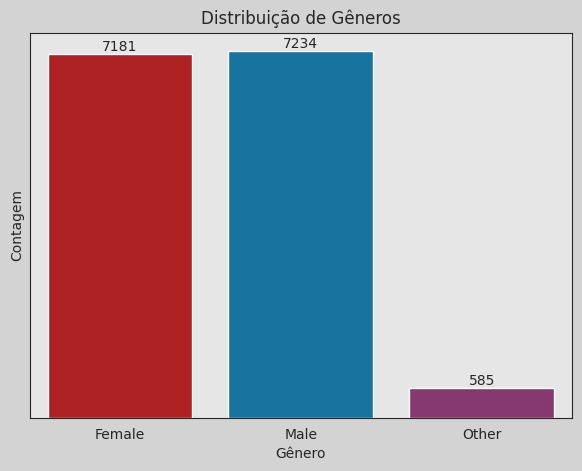

In [408]:
import matplotlib.pyplot as plt

cores_por_genero = {
     'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

fundo = '#E6E6E6'

plt.figure(figsize=(7, 5), facecolor='lightgrey')

ax = sns.countplot(
    x='gender',
    data=df,
    hue='gender',
    palette=cores_por_genero,
    legend=False
)

ax.set_facecolor(fundo)

for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        text=str(int(altura)),
        xy=(p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribuição de Gêneros')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.yticks([])

plt.show()


A partir do gráfico acima é possível avaliar que o dataset é balanceado em relação aos gêneros feminino e masculino, com um número estatisticamente irrelevante de usuários intitulados como "outro" gênero.

###Distribuição por Ocupação

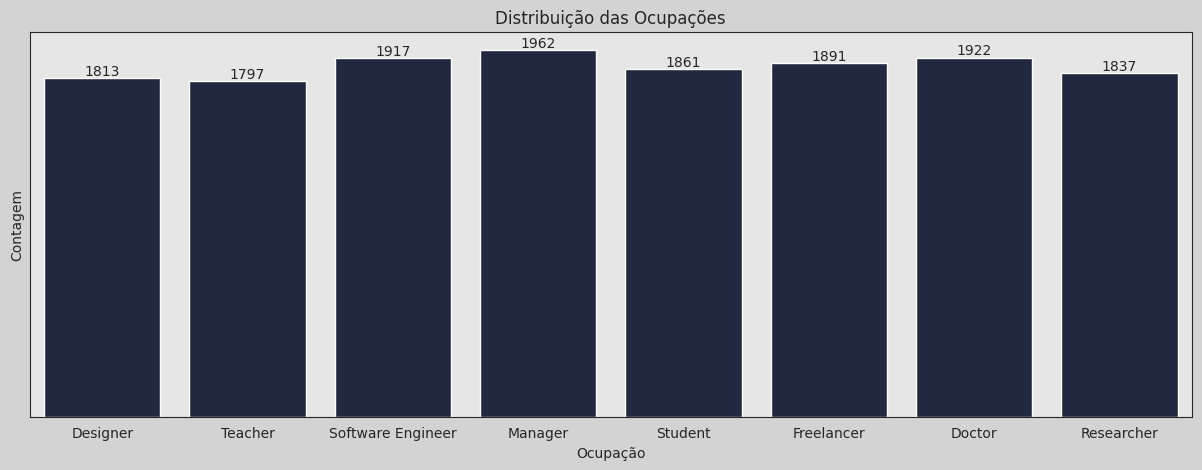

In [409]:
# Define o tamanho da figura e a cor de fundo geral
plt.figure(figsize=(15, 5), facecolor='lightgrey')

# Cor de fundo que será aplicada ao gráfico
fundo = '#E6E6E6'

# Cria um gráfico de contagem (countplot) para visualizar a distribuição das ocupações
ax = sns.countplot(
    x='occupation',
    data=df,
    color='#1E2546'   # Cor das barras
)

# Define a cor de fundo da área interna do gráfico
ax.set_facecolor(fundo)

# Adiciona rótulos numéricos acima de cada barra
for p in ax.patches:
    altura = p.get_height()  # Altura da barra (quantidade)
    ax.annotate(
        text=str(int(altura)),  # Texto exibido (convertido para inteiro)
        xy=(p.get_x() + p.get_width() / 2, altura),  # Posição do texto
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=10
    )

# Título e rótulos dos eixos
plt.title('Distribuição das Ocupações')
plt.xlabel('Ocupação')
plt.ylabel('Contagem')

# Remove os valores do eixo Y para deixar o visual mais limpo
plt.yticks([])

# Exibe o gráfico
plt.show()


Também é possível identificar equilibrio entre as profissões que participaram da amostragem. Todas entre 1.700 e 1900.

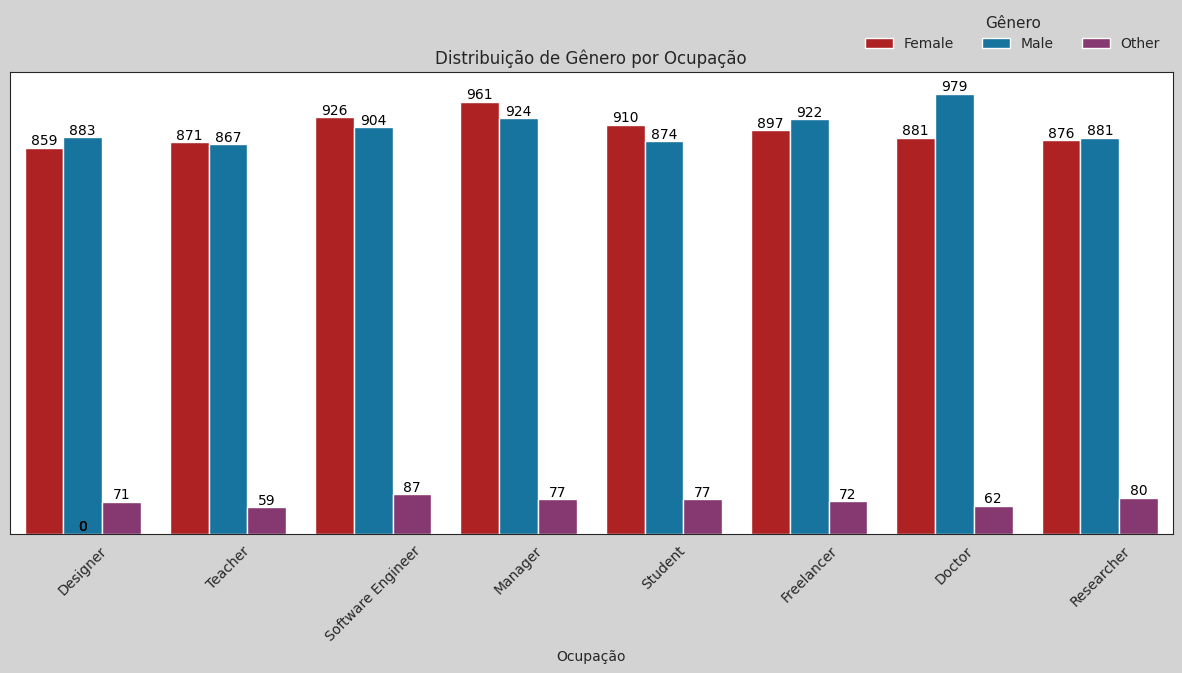

In [410]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

fundo = '#FFFFFF'

plt.figure(figsize=(15, 6), facecolor='lightgrey')  # fundo da figura

ax = sns.countplot(
    x='occupation',
    data=df,
    hue='gender',
    palette=cores_por_genero
)

ax.set_facecolor(fundo)

ax.legend(
    title='Gênero',
    loc='upper right',
    bbox_to_anchor=(1, 1.15),  # move a legenda para fora do gráfico
    frameon=False,             # fundo transparente
    ncol=3,                    # uma linha
    fontsize=10,
    title_fontsize=11
)

ax.legend(
    title='Gênero',
    loc='upper right',
    bbox_to_anchor=(1, 1.15),  # move a legenda para fora do gráfico
    frameon=False,             # fundo transparente
    ncol=3,                    # uma linha
    fontsize=10,
    title_fontsize=11

)


for p in ax.patches:
    altura = p.get_height()
    ax.annotate(
        text=str(int(altura)),
        xy=(p.get_x() + p.get_width() / 2, altura),
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'   # cor da fonte
    )

plt.title('Distribuição de Gênero por Ocupação')
plt.xlabel('Ocupação')
plt.ylabel('')

plt.yticks([])
plt.xticks(rotation=45)

plt.show()

Através do gráfico acima é possível dentificar que a distribuição de gêneros entre as ocupações se mantêm equilibrada para cada um dos três gêneros identificados nos dados.

#Estatística Descritiva

In [411]:
# estatísticas descritivas básicas do dataset
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


In [412]:
df.describe(include='object') #Variáveis categóricas

,gender,occupation
count,15000,15000
unique,3,8
top,Male,Manager
freq,7234,1962


In [413]:
df.isna().sum() #total de NaN por coluna

,0
user_id,0
age,0
gender,0
occupation,0
daily_screen_time_hours,0
phone_usage_before_sleep_minutes,0
sleep_duration_hours,0
sleep_quality_score,0
stress_level,0
caffeine_intake_cups,0


In [414]:
df.duplicated().sum() #número de valores duplicados

np.int64(0)

##Detecção de Outliers

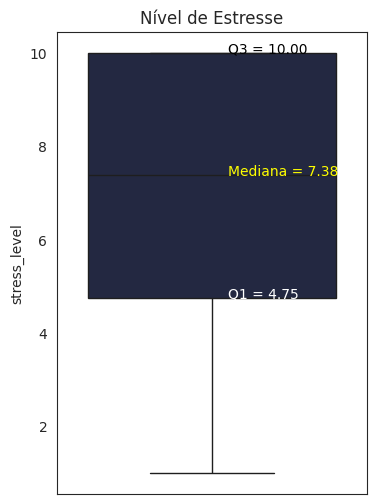

In [415]:
col = "stress_level"

q1 = df[col].quantile(0.25)
q2 = df[col].quantile(0.50)
q3 = df[col].quantile(0.75)

plt.figure(figsize=(4,6))
sns.boxplot(y=df[col], color="#1E2546")

# Anotações dos quartis
plt.text(0.05, q1, f"Q1 = {q1:.2f}", color="WHITE")
plt.text(0.05, q2, f"Mediana = {q2:.2f}", color="YELLOW")
plt.text(0.05, q3, f"Q3 = {q3:.2f}", color="black")

plt.title("Nível de Estresse")
plt.ylabel(col)
plt.show()

O gráfico acima revela que embora os níveis de estresse possam variar entre 1 e 10, a maior parte dos usuários apresentam entre 5 e 10 neste quesito.
A mediana está em 7,38, mostrando que metade dos usuários apresentam níveis altos de estresse (acima de 7), tendência de estresse elevado. q3 = 10 permite interpretar que 75% dos usuários apresentam índices altíssimos de níveis de estresse.
Não foram detectados outliers para este atributo.

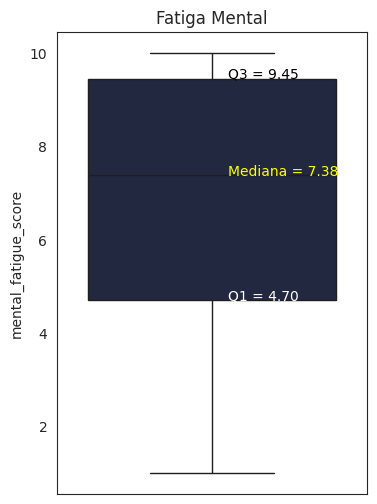

In [416]:
col = "mental_fatigue_score"

q1 = df[col].quantile(0.25)
q2 = df[col].quantile(0.50)
q3 = df[col].quantile(0.75)

plt.figure(figsize=(4,6))
sns.boxplot(y=df[col], color="#1E2546")

# Anotações dos quartis
plt.text(0.05, q1, f"Q1 = {q1:.2f}", color="white")
plt.text(0.05, q2, f"Mediana = {q2:.2f}", color="yellow")
plt.text(0.05, q3, f"Q3 = {q3:.2f}", color="black")

plt.title("Fatiga Mental")
plt.ylabel(col)
plt.show()

O gráfico acima revela que embora os níveis de fadiga mental possam variar entre 1 e 10, maior parte deles está concentrada etre 4 e 9. A mediana igual a 7.38, indica tendência para valores altos de fadiga mental. Q3= 9,45 indica que 75% dos usuários estão com os níveis altissimos de fadiga mental.

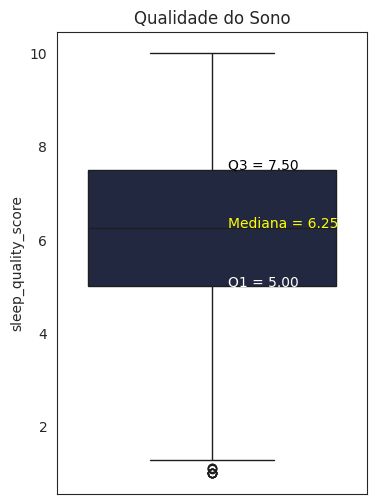

In [417]:
col = "sleep_quality_score"

q1 = df[col].quantile(0.25)
q2 = df[col].quantile(0.50)
q3 = df[col].quantile(0.75)

plt.figure(figsize=(4,6))
sns.boxplot(y=df[col], color="#1E2546")

# Anotações dos quartis
plt.text(0.05, q1, f"Q1 = {q1:.2f}", color="white")
plt.text(0.05, q2, f"Mediana = {q2:.2f}", color="yellow")
plt.text(0.05, q3, f"Q3 = {q3:.2f}", color="black")

plt.title("Qualidade do Sono")
plt.ylabel(col)
plt.show()

O gráfico acima revela que embora os níveis de qualidade do sono possa variar entre 1 a 10, a distribuição está cncentrada entre 5 e 7,5, com mediana em 6,25. Existem usuários com qualidade de sono abaixo de 2, como domonstram os outliers. Q1 = 5 sinaliza que 25% dos usuários dormem mal. A mediana =6.25 implica que a qualidade do sono de mateda dos usuários é razoável. Q3= 7,5 indica que apenas 25% dos usuários tem qualidade de sono realmente boa.

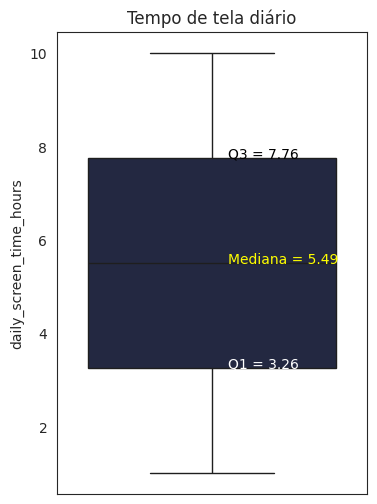

In [418]:
col = "daily_screen_time_hours"

q1 = df[col].quantile(0.25)
q2 = df[col].quantile(0.50)
q3 = df[col].quantile(0.75)

plt.figure(figsize=(4,6))
sns.boxplot(y=df[col], color="#1E2546")

# Anotações dos quartis
plt.text(0.05, q1, f"Q1 = {q1:.2f}", color="white")
plt.text(0.05, q2, f"Mediana = {q2:.2f}", color="yellow")
plt.text(0.05, q3, f"Q3 = {q3:.2f}", color="black")

plt.title("Tempo de tela diário")
plt.ylabel(col)
plt.show()

O gráfico acima revela que a distribuição do temp de uso de telas diariamente está entre 3,26 e 7,76 horas com mediana em 5,49 horas. A variação entre 1 e 10hras por dia indica grande amplitude nos hábitos entre os usuários. Q1= 3,26 indica que 25% das pessoas usam telas entre 3,26 horas ou menor por dia.
Q3=7,6 indica que 75% das pessoas usam telas por 7,76 horas e que o quartil superior usam telas por quase 8h por dia. Mostrando um uso elevado pelos usuários.

## Relação entre tempo de tela e nível de estresse por gênero.

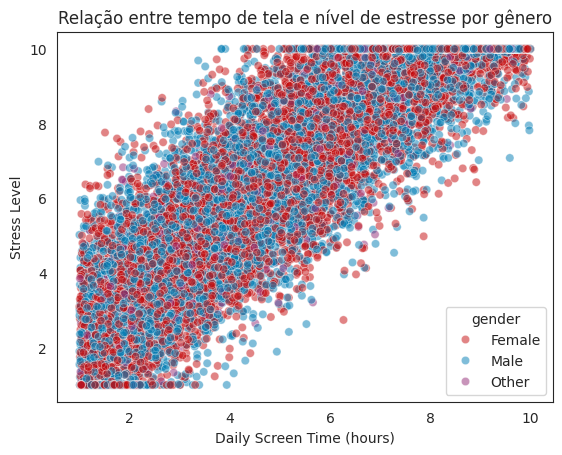

In [419]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

sns.scatterplot(
    x='daily_screen_time_hours',
    y='stress_level',
    data=df,
    alpha=0.5,
    hue='gender', # Adiciona cores baseadas no gênero
    palette=cores_por_genero # Usa a paleta de cores personalizada
)

plt.title("Relação entre tempo de tela e nível de estresse por gênero")
plt.xlabel("Daily Screen Time (hours)")
plt.ylabel("Stress Level")

plt.show()

O gráfico acima demonstra a distribuição dos pontos e sugere uma tendência positiva: conforme o tempo de uso de tela aumenta, o nível de estresse também tende a aumentar. Há um padrão visível de concentração de pontos mais altos de estresse em valores maiores de horas de tela.

Analisando por gênero é possível inferir:

Que as Mulheres (vermelho) parecem mais concentradas em níveis de estresse mais altos, especialmente quando o tempo de tela ultrapassa 5 horas.

Enquanto os homens (azul) aparecem mais distribuídos, com alguns pontos de estresse alto, mas também muitos em níveis médios.

Os Outros gêneros (roxo) têm menos pontos, mas seguem a mesma tendência geral de aumento de estresse com mais horas de tela


##Matriz de Correlação de Pearson

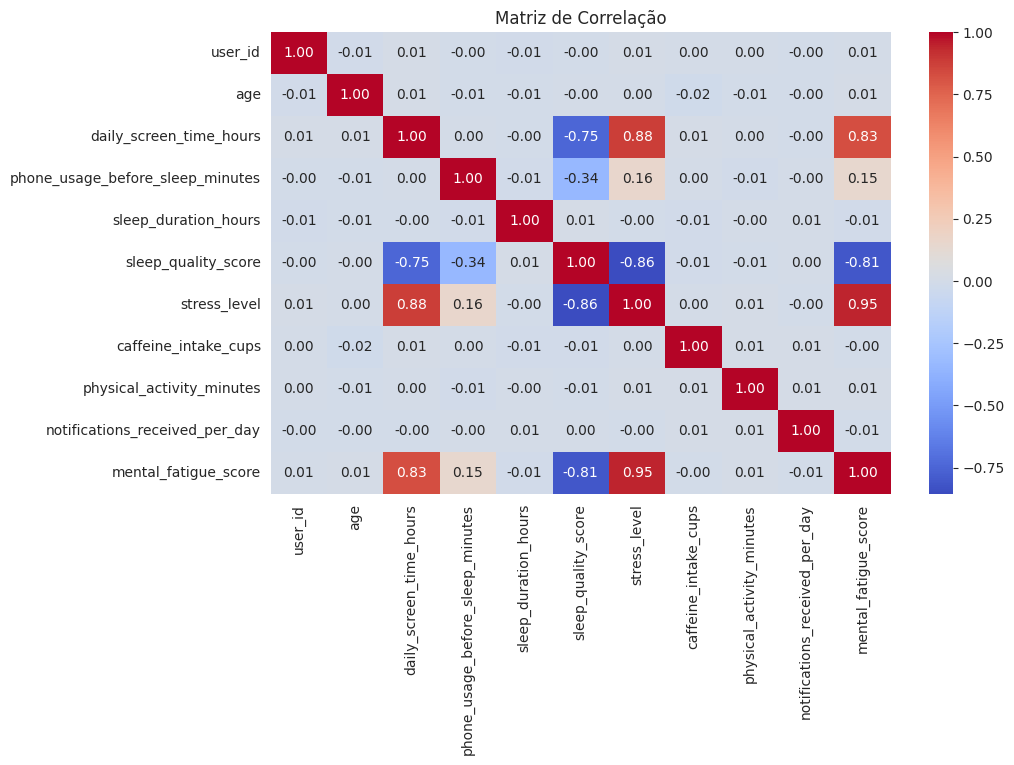

In [420]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")

plt.show()



*   Correlação Positiva:
Tempo de tela diário (daily_screen_time_hours) e Nível de EStresse  (Stress_level) [0.88] e Tempo de tela diário (daily_screen_time_hours) e  fadiga mental (mental_fatigue_score)[0.83].

Os dados sugerem que quanto maior o tempo de tela diário, maiores tendem a ser os níveis de estresse e fadiga mental.

*   Correlação Positiva:
Nível de estresse (stress_level) e Fadiga mental (mental_fatigue_score) [-0.95].
Os dados corroboram o que já era esperado, visto que ambos os conceitos estão intimamente relacionados.


*   Correlação Negativa:
Tempo de uso do telefone antes de dormir (phone_usage_before_sleep_minutes) e qualidade do sono (sleep_quality_score) [(-0.34].

Trata-se de uma correlação mais fraca, porém significativa. O uso de telefone antes de dormir pode causar diminuição na qualidade do sono.


*   Correlação Negativa
Tempo de tela diário (daily_screen_time_hours) e qualidade do sono (sleep quality score) [-0.75].

Os dados indicam que quanto maior o tempo de tela, menor é a qualidade do sono.

*   Correlação Negativa
Qualidade do sono (sleep_quality_score), Nível de Estresse (stress_level)[-0.86] e Qualidade do sono (sleep_quality_score)  e fadiga mental mental_fatigue_score [-0.81].

Os dados apontam que uma pior qualidade do sono está associada a níveis mais altos de estresse e fadiga mental.


## Médias e Distribuições

In [421]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


### Distribuição do tempo de uso de smartphones por gênero

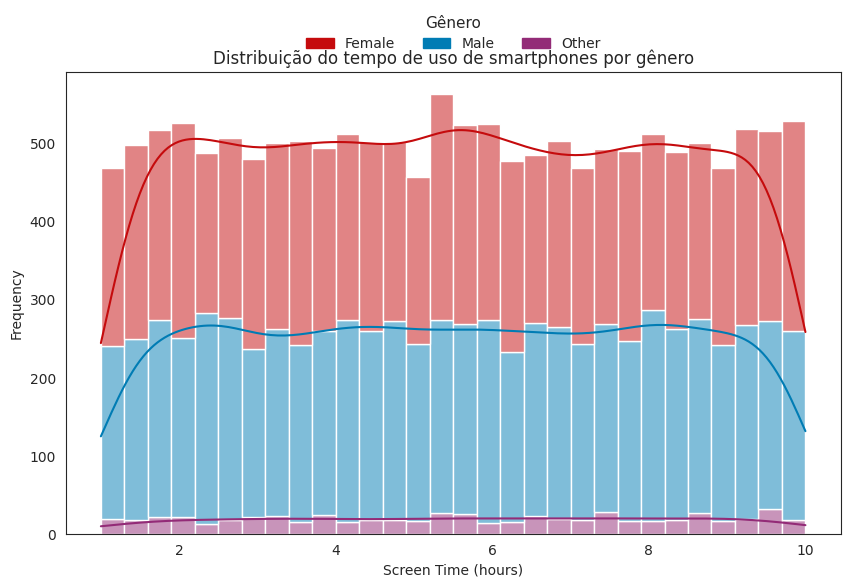

In [422]:
import matplotlib.patches as mpatches

cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='daily_screen_time_hours',
    bins=30,
    kde=True,
    hue='gender',
    multiple='stack',
    palette=cores_por_genero,
    legend=False # Prevent seaborn from creating its own legend automatically
)

# Create custom legend handles with color swatches
legend_handles = []
for gender, color in cores_por_genero.items():
    legend_handles.append(mpatches.Patch(color=color, label=gender))

# Legenda posicionada no topo
ax.legend(
    handles=legend_handles,
    title='Gênero',
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),  # Centraliza e coloca acima do gráfico
    frameon=False,
    ncol=3,
    fontsize=10,
    title_fontsize=11
)

plt.title("Distribuição do tempo de uso de smartphones por gênero")
plt.xlabel("Screen Time (hours)")
plt.ylabel("Frequency")

plt.show()

O formato do histograma acima indica que o tempo de tela está distribuído de maneira relativamente uniforme entre 1 e 10 horas, com pequenas variações entre as barras. A curva KDE suaviza essa distribuição e mostra que não há um único pico dominante, sugerindo que os participantes se espalham de forma ampla ao longo das faixas de uso.

### Distribuição do nível de estresse por ocupação e gênero

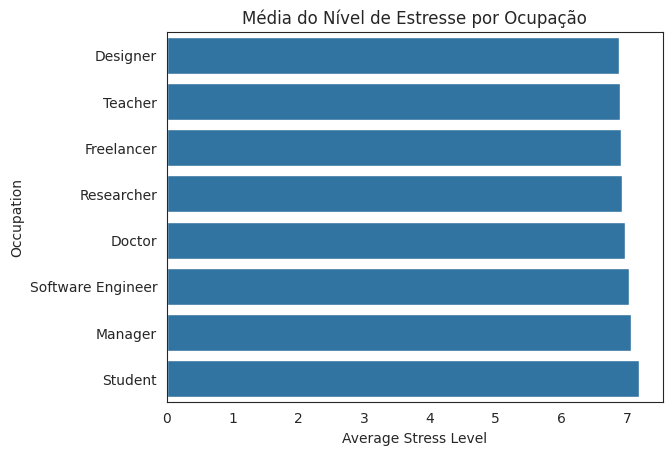

In [423]:
occupation_stress = df.groupby('occupation')['stress_level'].mean().sort_values()

sns.barplot(
    x=occupation_stress.values,
    y=occupation_stress.index
)

plt.title("Média do Nível de Estresse por Ocupação")
plt.xlabel("Average Stress Level")
plt.ylabel("Occupation")

plt.show()

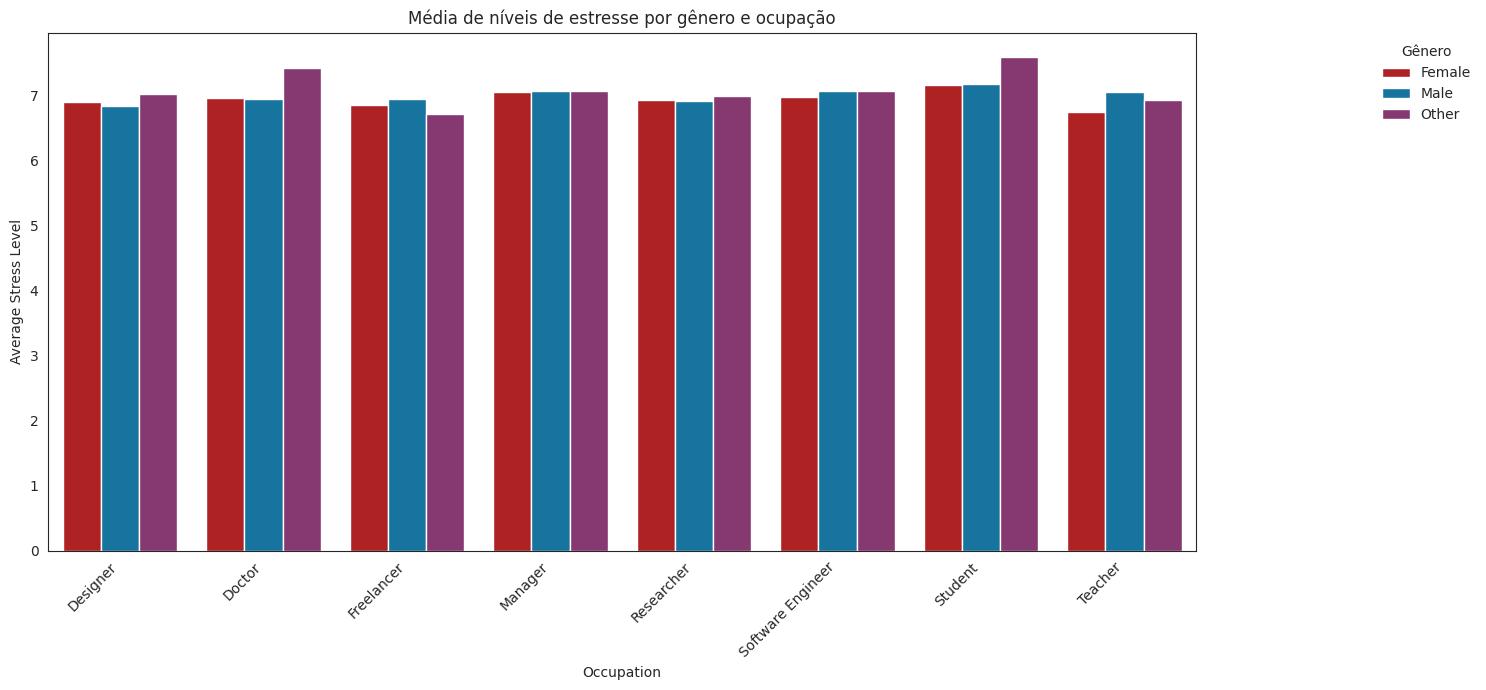

In [424]:

tabela = 'https://raw.githubusercontent.com/larissamitrof-collab/MVP-1/main/sleep_mobile_stress_dataset_15000.csv'
df = pd.read_csv(tabela)
df = df.drop_duplicates()
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}


occupation_gender_stress = df.groupby(['occupation', 'gender'])['stress_level'].mean().reset_index()

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    x='occupation',
    y='stress_level',
    hue='gender', # usa cores diferentes por gênero
    data=occupation_gender_stress,
    palette=cores_por_genero
)

ax.legend(
    title='Gênero',
    loc='upper right',
    bbox_to_anchor=(1.25, 1), # Posiciona legenda fora da área de grafico
    frameon=False,
    ncol=1 # mostra legenda em uma coluna unica
)

plt.title("Média de níveis de estresse por gênero e ocupação")
plt.xlabel("Occupation")
plt.ylabel("Average Stress Level")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Os dois gráficos acima demonstram que a média de nível de estresse entre diferentes ocupações e gêneros não apresenta diferença significativa, o que permite inferir que o  estresse pode estar relacionado com fatores transversais como o tempo de tela e horas de sono, por exemplo.

### Média Geral dos Atributos



In [425]:
tabela = (df.drop(columns=['user_id']).describe().loc['mean'])

tabela = tabela.round(2)

tabela



,mean
age,38.49
daily_screen_time_hours,5.50
phone_usage_before_sleep_minutes,59.71
sleep_duration_hours,6.51
sleep_quality_score,6.25
stress_level,6.98
caffeine_intake_cups,2.00
physical_activity_minutes,59.16
notifications_received_per_day,160.89
mental_fatigue_score,6.87


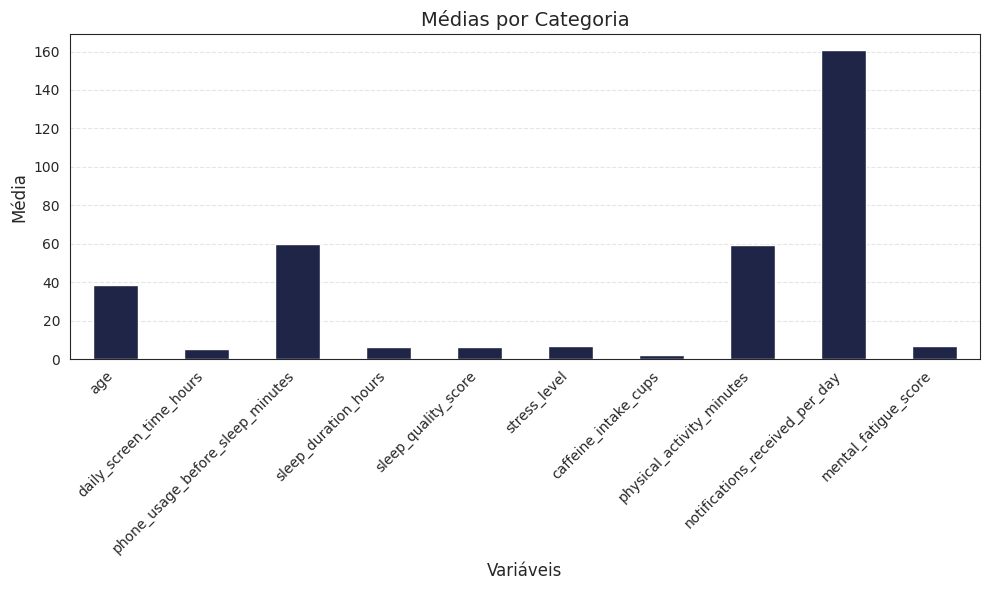

In [426]:
tabela = (df.drop(columns=['user_id']).describe().loc['mean'])

tabela = tabela.round(2)

tabela

plt.figure(figsize=(10,6))
tabela.plot(kind='bar', color='#1E2546')

plt.title('Médias por Categoria', fontsize=14)
plt.ylabel('Média', fontsize=12)
plt.xlabel('Variáveis', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Média por Gênero

In [427]:
tabela = (
    df.drop(columns=['user_id', 'age'])
      .groupby('gender')
      .mean(numeric_only=True)
      .T
)

tabela['dif'] = tabela.max(axis=1) - tabela.min(axis=1)

tabela_ordenada = tabela.sort_values('dif', ascending=False)

tabela_ordenada2 = tabela_ordenada.round(2)

tabela_ordenada2



gender,Female,Male,Other,dif
notifications_received_per_day,160.40,161.53,159.01,2.52
physical_activity_minutes,58.89,59.28,60.90,2.01
phone_usage_before_sleep_minutes,59.18,60.29,59.03,1.26
stress_level,6.95,7.00,7.10,0.15
daily_screen_time_hours,5.49,5.51,5.60,0.11
sleep_duration_hours,6.50,6.51,6.58,0.08
sleep_quality_score,6.27,6.22,6.27,0.05
mental_fatigue_score,6.85,6.89,6.89,0.04
caffeine_intake_cups,1.99,2.01,1.99,0.02


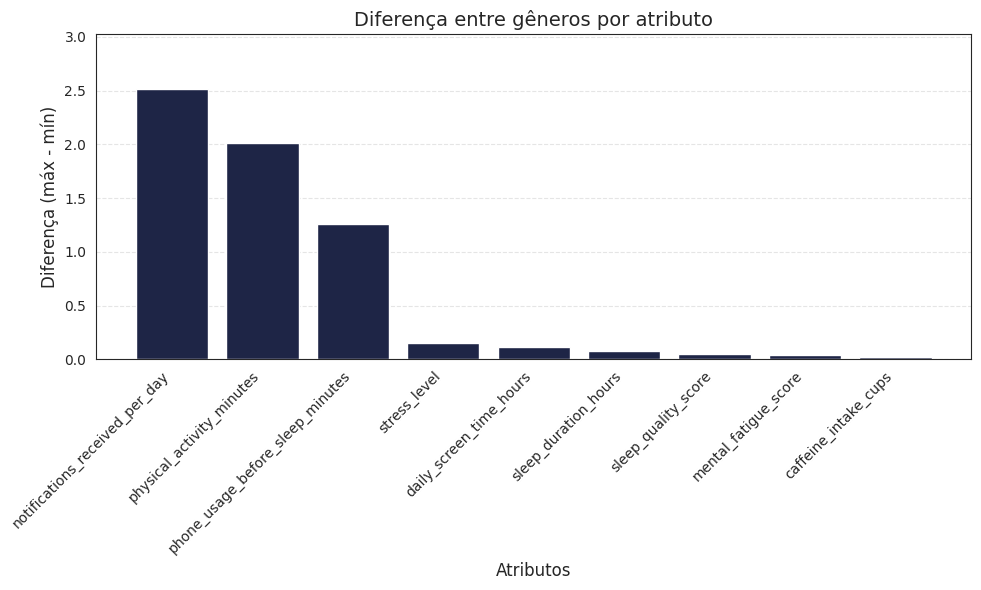

In [428]:
plt.figure(figsize=(10,6))

plt.bar(
    tabela_ordenada2.index,
    tabela_ordenada2['dif'],
    color='#1e2546'
)

plt.title('Diferença entre gêneros por atributo', fontsize=14)
plt.ylabel('Diferença (máx - mín)', fontsize=12)
plt.xlabel('Atributos', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.ylim(0, tabela_ordenada['dif'].max() + 0.5)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

O Gráfico e a tabela acima mostram a diferença entre os gêneros para cada atributo da pesquisa. Destacam-se os atributos de quantidade de notificações por dia, com um número maior para homens, seguido de minutos de atividade física, também com homens obtendo maior tempo e o uso de telefone antes de dormir, sendo o valor maior para usuários identificados pelo gênero "outros".

### Média por Ocupação

In [429]:
tabela = (
    df.drop(columns=['user_id', 'age'])
      .groupby('occupation')
      .mean(numeric_only=True)
      .T
)

tabela['dif'] = tabela.max(axis=1) - tabela.min(axis=1)

tabela_ordenada = tabela.sort_values('dif', ascending=False)

tabela_ordenada1 = tabela_ordenada.round(2)

tabela_ordenada1




occupation,Designer,Doctor,Freelancer,Manager,Researcher,Software Engineer,Student,Teacher,dif
notifications_received_per_day,160.69,161.80,159.54,158.26,159.68,163.40,164.63,159.11,6.37
phone_usage_before_sleep_minutes,58.72,60.53,60.42,59.67,59.38,60.48,60.37,57.96,2.57
physical_activity_minutes,59.81,59.52,59.13,58.03,59.02,59.58,58.53,59.71,1.78
stress_level,6.87,6.97,6.90,7.06,6.92,7.02,7.18,6.90,0.31
mental_fatigue_score,6.75,6.87,6.81,6.97,6.80,6.92,7.04,6.81,0.30
daily_screen_time_hours,5.45,5.49,5.41,5.54,5.46,5.55,5.63,5.47,0.23
sleep_quality_score,6.33,6.26,6.28,6.21,6.29,6.20,6.11,6.30,0.21
caffeine_intake_cups,1.97,2.02,2.05,2.01,2.02,1.96,2.01,1.95,0.10
sleep_duration_hours,6.54,6.45,6.49,6.52,6.50,6.51,6.53,6.54,0.10


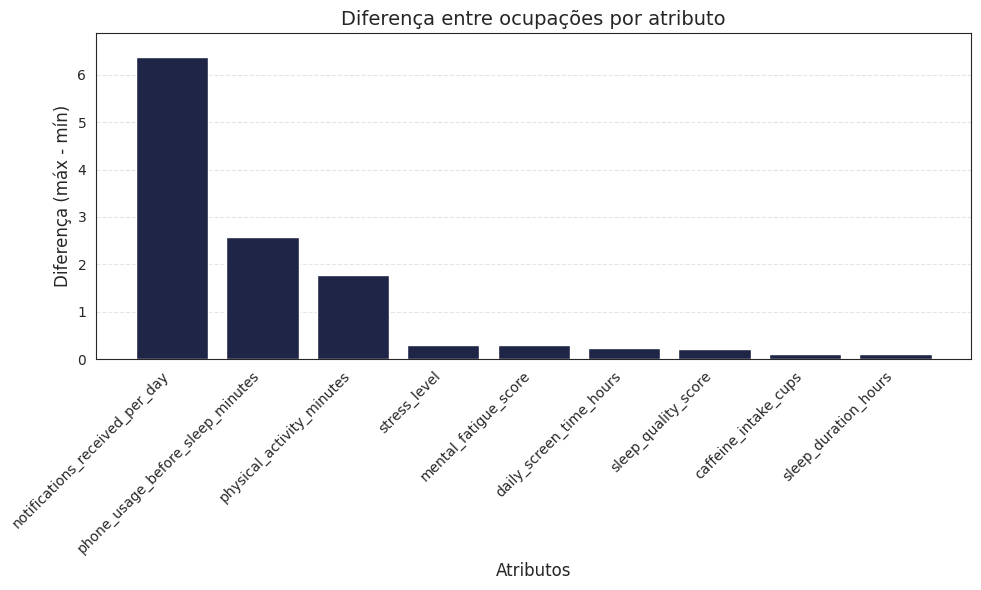

In [430]:
plt.figure(figsize=(10,6))

plt.bar(
    tabela_ordenada1.index,
    tabela_ordenada1['dif'],
    color='#1e2546'
)

plt.title('Diferença entre ocupações por atributo', fontsize=14)
plt.ylabel('Diferença (máx - mín)', fontsize=12)
plt.xlabel('Atributos', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.ylim(0, tabela_ordenada['dif'].max() + 0.5)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

A maior diferença entre as ocupações para cada um dos atributos foram: Quantidade de notificações por dia, destacando estudantes, engenheiros e médico com maiores valores. O atributo 'uso de telefone antes de dormir' também apresentou diferença significativa entre as ocupações, com destaque para Doutor, Freelancer, Engenheiro e estudantes. A realização de atividade física mostrou diferença, principalmente entre Designer, professor, engenheiro, estudante e doutor.



*   Notifications received per day:

Atributo com maior disparidade entre as ocupações. A análise sugere que estudantes e profissionais de tecnologia lidam com maior fluxo de estímulos digitais, enquanto gestores e professores recebem menos interrupções.

*   Phone Use before sleep:

A variação é pequena, porém significativa. Profissionais autônomos e da saúde parecem usar mais o celular à noite, possivelmente por demandas irregulares inerentes ao perfil de ocupação.


*   Physical activity:

Diferença moderada, mas importante para salientar a diferença na ocupação de gestores. Sugerindo rotinas mais sedentárias. Enquanto Designer e Teacher apresentaram maiores valores.


*   Stress level:

Pouca diferença entre as ocupações, mas apresentam nuances como valores ligeiramente mais altos de estresse em gestore e estutantes.


*   Mental fatigue:

Seguindo o mesmo padrão de estresse, por estarem relacionados diretamente. A ocupação de estudante lidera com maior índice.

*   Tempo de tela:

Estudantes e engenheiros de software apresentam maiores valores, enquanto frelancer apresenta menor. É possível inferir que profissões relacionadas a tecnologia e estudo estejam naturalmente utilizando  celulares e telas por mais tempo.


*   Sleep Quality:

Aqui, mais uma vez os estudantes apresentam maior índice em relação Designer e Professores. O que pode ser interpretado como consequência de rotinas irregulares e alta carga mental.

*   Caffeine intake cups:

Apresenta menor variação dentre as ocupações. O consumo de cafeína é semelhante independente das ocupações.


*   Duration sleep

A menor variação dentre as ocupações. Todas as ocupações dormem praticamente o mesmo número de horas. Este dado é impactante quando avaliamos que a qualidade do sono e índices de estresse e fatiga mental apresentam maiores variações dentre as profissões.

### Desvio Padrão
### Visualização do Desvio Padrão dos Atributos Numéricos

Este gráfico de barras exibe o desvio padrão de cada atributo numérico no dataset, excluindo 'user_id' e 'age'.

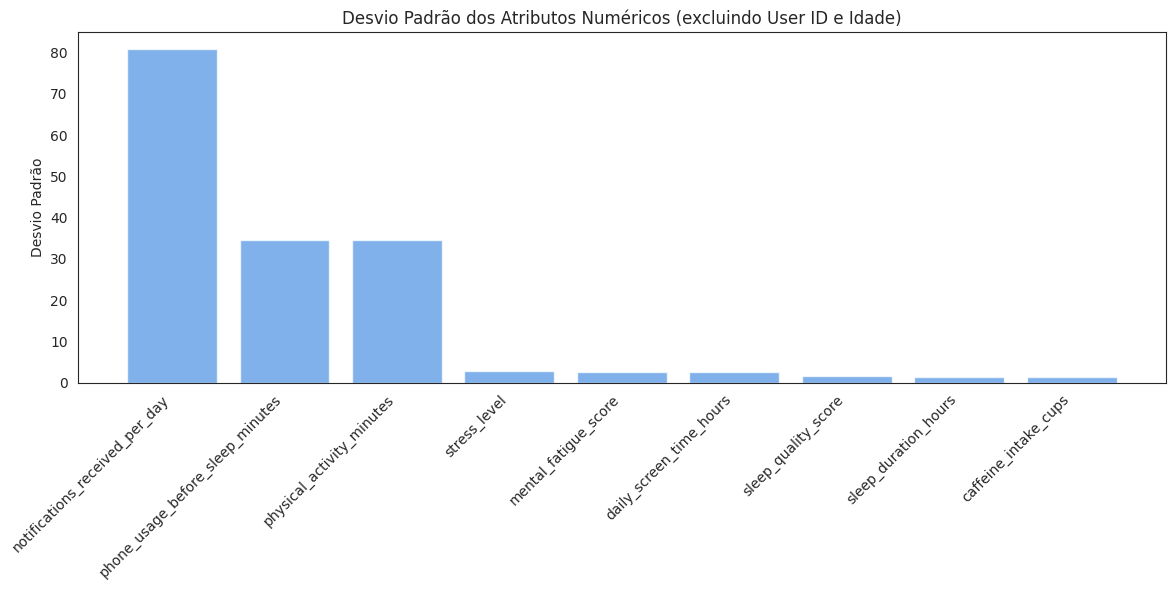

In [431]:
# Calcula o desvio padrão e ordena do maior para o menor
std_values = (
    df.drop(columns=['user_id', 'age'])
      .describe()
      .loc['std']
      .sort_values(ascending=False)
)

# Configurações do gráfico
plt.figure(figsize=(12, 6))

# Barras ordenadas
plt.bar(std_values.index, std_values, color="#4a90e2", alpha=0.7)

# Ajustes visuais
plt.xticks(rotation=45, ha='right')
plt.ylabel("Desvio Padrão")
plt.title("Desvio Padrão dos Atributos Numéricos (excluindo User ID e Idade)")

plt.tight_layout()
plt.show()


A análise do desvio padrão segue o mesmo padrão das médias, com pequenas variaçoes em relação a caffeine intake cups e sleep duration. Este dado confirma a análise realizada.

### Distribuição do nível de estresse por gênero

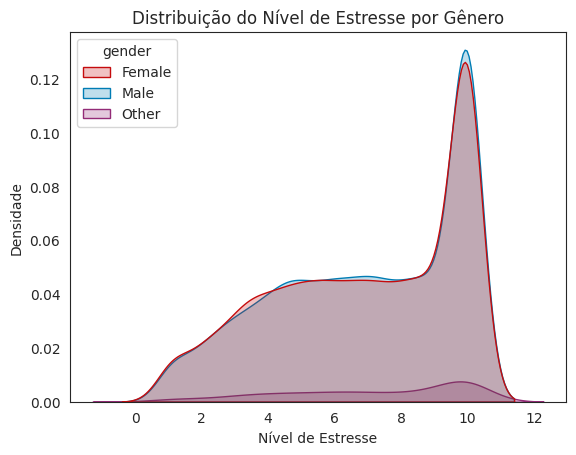

In [432]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

sns.kdeplot(
    x=df['stress_level'],
    fill=True,
    hue=df['gender'], # Adiciona o gênero como diferenciador
    palette=cores_por_genero # Usa a paleta de cores personalizada
)

plt.title("Distribuição do Nível de Estresse por Gênero")
plt.xlabel("Nível de Estresse")
plt.ylabel("Densidade")

plt.show()

Assim como as demais variáveis, o nível de estresse não representa diferenças significativas entre os gêneros.

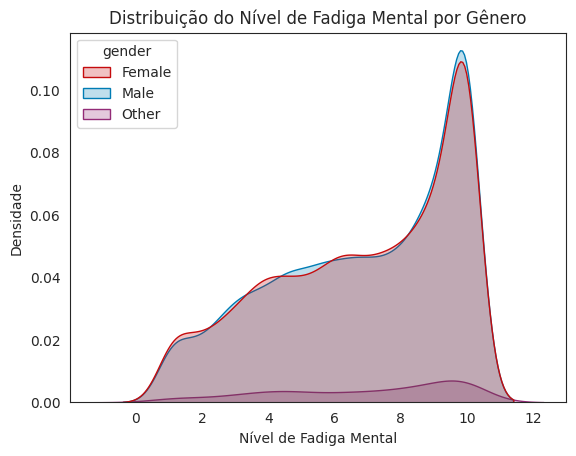

In [455]:
cores_por_genero = {
    'Female': '#c50b0d',
    'Male': '#007cb4',
    'Other': '#932b77'
}

sns.kdeplot(
    x=df['mental_fatigue_score'],
    fill=True,
    hue=df['gender'], # Adiciona o gênero como diferenciador
    palette=cores_por_genero # Usa a paleta de cores personalizada
)

plt.title("Distribuição do Nível de Fadiga Mental por Gênero")
plt.xlabel("Nível de Fadiga Mental")
plt.ylabel("Densidade")

plt.show()

### Correlação de atributos com nível de estresse



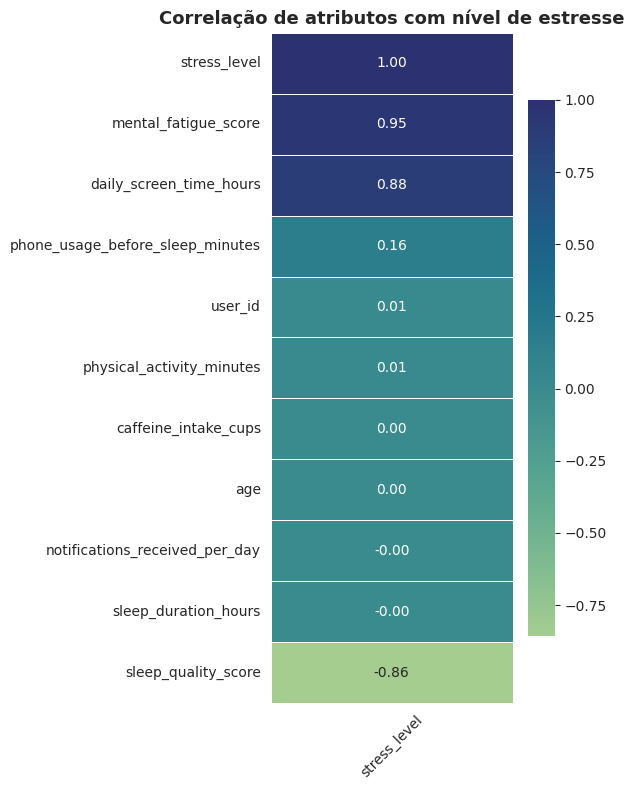

In [434]:
sns.set_style("white")

corr_stress_level = (
    df.select_dtypes(include="number")
    .corr()[["stress_level"]]
    .sort_values(by="stress_level", ascending=False))

plt.figure(figsize=(6,8))

sns.heatmap(
    corr_stress_level,
    annot=True,
    fmt=".2f",
    cmap="crest",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},)

plt.title("Correlação de atributos com nível de estresse", fontsize=13, weight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

O gráfico indica que o estresse dos usuários está muito mais ligado a fatores cognitivos e comportamentais do que a características demográficas ou hábitos isolados

# Pré-Processamento

In [435]:
df = df.drop_duplicates()

In [436]:
# 1. One-hot encode 'gender'
# Remoção da coluna original 'gender' e adição as colunas one-hot encoded.
df = pd.get_dummies(df, columns=['gender'], drop_first=False)

# 2. Frequency encode 'occupation'
freq = df['occupation'].value_counts(normalize=True)
df['occupation_encoded'] = df['occupation'].map(freq)
df = df.drop(columns=['occupation'])

X = df.drop('sleep_quality_score', axis=1)
y = df['sleep_quality_score']

In [437]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Normalização

In [445]:
scaler_norm = MinMaxScaler()

### Codificação dos Gêneros e Ocupações
Transformação de cada ocupação em um número de 0 a 1 baseado na proporção de usuários na ocupação e nos generos. Esta função foi escolhida por permitir a manutenção da informação, evitar ordem artificial, não explodir número de colunas e apresentar bom funcionamento em modelos clustering.

Para o Gênero foi utilizado one-hot encoding, devido a um número pequeno de variáveis.

In [446]:
df = pd.get_dummies(df, columns=['gender'], drop_first=False)


In [ ]:
df_encoded.head()

In [ ]:
freq = df['occupation'].value_counts(normalize=True)
df['occupation_encoded'] = df['occupation'].map(freq)

freq.head()


In [447]:
cols_to_scale = [
    'age',
    'daily_screen_time_hours',
    'phone_usage_before_sleep_minutes',
    'sleep_duration_hours',
    'stress_level',
    'caffeine_intake_cups',
    'physical_activity_minutes',
    'notifications_received_per_day',
    'mental_fatigue_score'
]


In [448]:
from sklearn.preprocessing import MinMaxScaler

scaler_norm = MinMaxScaler()

# aprende min e max só das colunas numéricas
scaler_norm.fit(X_train[cols_to_scale])

# cria cópias para não perder as colunas categóricas
X_train_normalized = X_train.copy()
X_test_normalized = X_test.copy()

# aplica a normalização apenas nas colunas numéricas
X_train_normalized[cols_to_scale] = scaler_norm.transform(X_train[cols_to_scale])
X_test_normalized[cols_to_scale] = scaler_norm.transform(X_test[cols_to_scale])


In [449]:
df_train_norm = pd.DataFrame(X_train_normalized, columns=X_train.columns)
print(df_train_norm.head())


       user_id       age  daily_screen_time_hours  \
9839      9840  0.609756                 0.466667   
9680      9681  0.317073                 0.322222   
7093      7094  0.097561                 0.006667   
11293    11294  0.609756                 0.703333   
820        821  0.463415                 0.828889   

       phone_usage_before_sleep_minutes  sleep_duration_hours  stress_level  \
9839                           0.394958                 0.466      0.822222   
9680                           0.420168                 0.330      0.543333   
7093                           0.722689                 0.974      0.000000   
11293                          0.966387                 0.168      1.000000   
820                            0.789916                 0.470      0.846667   

       caffeine_intake_cups  physical_activity_minutes  \
9839                   0.75                   0.521008   
9680                   0.00                   0.033613   
7093                   0.25     

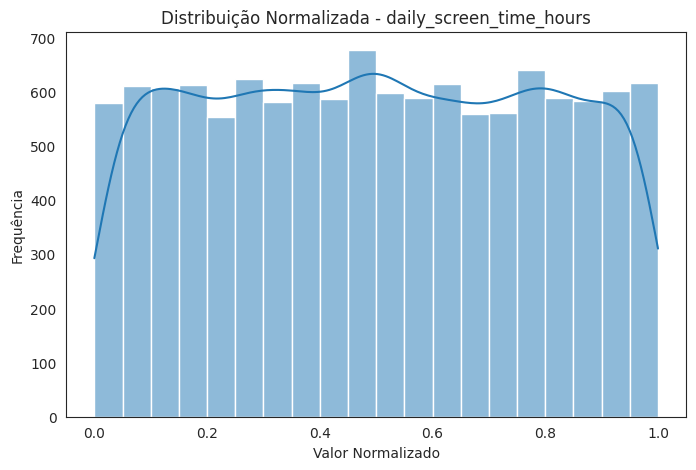

In [450]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df_train_norm['daily_screen_time_hours'], bins=20, kde=True)

plt.title('Distribuição Normalizada - daily_screen_time_hours')
plt.xlabel('Valor Normalizado')
plt.ylabel('Frequência')
plt.show()


A distribuição normalizada mostra variabilidade dos tempos de uso de telas, com tempo moderado em sua maioria.

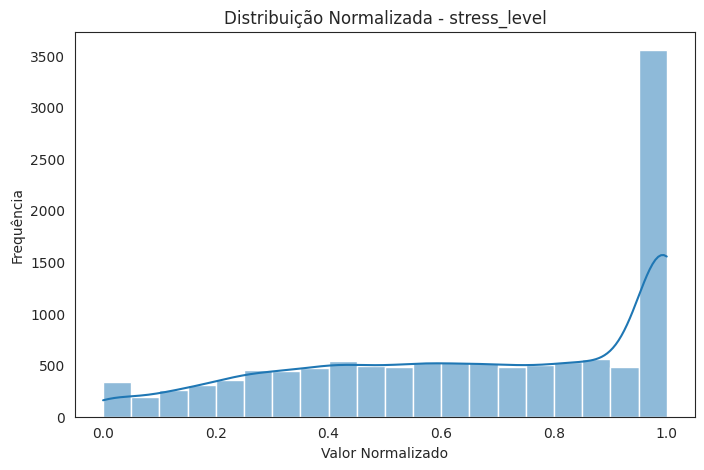

In [451]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df_train_norm['stress_level'], bins=20, kde=True)

plt.title('Distribuição Normalizada - stress_level')
plt.xlabel('Valor Normalizado')
plt.ylabel('Frequência')
plt.show()

A curva mostra uma distribuição enviesada à direita, corroborando com as análises anteriores onde os níveis de estresse são altos independente da ocupação ou gênero dos usuários.

#Resposta às Hipóteses

## Hipótese 1: Existe diferenças entre gêneros ou ocupação em relação ao tempo de uso de tela e níveis de estresse?

Não foram identificadas diferenças significativas entre gênero e/ou ocupação para o atributo "nível de estresse". Tendo este um valor elevado como um todo, podendo inferir que hábitos cotidianos diferentes podem gerar níveis altos de estresse.

## Hipótese 2: O uso de telas impacta diferentemente homens emulheres quanto a qualidade do sono?

Assim como níveis de estresse, a qualidade do sono não apresentou diferenças significativas para gêneros. Este atributo apresentou resultados baixos para maioria dos usuários.

##Hipótese 3: O nível de esgotamento mental é maior em mulheres ou homens?

Seguindo a mesma linha dos níveis de estresse e qualidade do sono, os níveis de fadiga mental não apresentam diferenças significativas entre homens e mulheres.

# Conclusão

Através das análises realizadas entende-se que independente de ocupação, gênero ou tempo de uso de telas,  os níveis de estresse e fadiga mental encontrados nos usuários foram altos em sua maioria, o que pode explicar a baixa qualidade do sono. Fatores que estão interligados e que expõem que diferentes hábitos de vida estão sendo afetados pelo uso de telas, sejam elas de telefones ou outros tipos. Estes dados nos leva a refletir sobre nossa saúde física e mental frente à revolução tecnológica.